In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('/content/global_air_quality_dataset.csv')

df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [5]:
print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Number of Rows and Columns:
(3660, 13)

Column Names:
Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')

Data Types:
Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object

Missing Values:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Duplicate Rows:
0


Important Columns:

AQI: Air Quality Index value.
PM2.5: Fine particulate matter pollution.
PM10: Dust particles in air.
NO2: Nitrogen dioxide gas level.
SO2: Sulfur dioxide gas level.
CO: Carbon monoxide level.
O3: Ozone level.
Temperature: Weather temperature.
Humidity: Moisture level in air.
Wind Speed: Speed of wind.
City and Country: Location information.
Date: Observation date.

In [6]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numerical values with mean
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Create Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Check dataset again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              3660 non-null   datetime64[ns]
 1   City              3660 non-null   object        
 2   Country           3660 non-null   object        
 3   AQI               3660 non-null   int64         
 4   PM2.5 (µg/m³)     3660 non-null   float64       
 5   PM10 (µg/m³)      3660 non-null   float64       
 6   NO2 (ppb)         3660 non-null   float64       
 7   SO2 (ppb)         3660 non-null   float64       
 8   CO (ppm)          3660 non-null   float64       
 9   O3 (ppb)          3660 non-null   float64       
 10  Temperature (°C)  3660 non-null   float64       
 11  Humidity (%)      3660 non-null   int64         
 12  Wind Speed (m/s)  3660 non-null   float64       
 13  Year              3660 non-null   int32         
 14  Month             3660 n

/tmp/ipykernel_4619/4037095902.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [7]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['AQI'].apply(aqi_category)

df[['AQI', 'AQI_Category']].head()

,AQI,AQI_Category
0,38,Good
1,280,Very Unhealthy
2,117,Unhealthy for Sensitive Groups
3,197,Unhealthy
4,187,Unhealthy


In [8]:
print("Mean AQI:", df['AQI'].mean())

print("Minimum AQI:", df['AQI'].min())

print("Maximum AQI:", df['AQI'].max())

print("Standard Deviation:", df['AQI'].std())

# Average AQI by Country
print("\nAverage AQI by Country:")
print(df.groupby('Country')['AQI'].mean())

# Highest AQI Location
highest = df.loc[df['AQI'].idxmax()]
print("\nHighest AQI Location:")
print(highest[['City', 'Country', 'AQI']])

# Lowest AQI Location
lowest = df.loc[df['AQI'].idxmin()]
print("\nLowest AQI Location:")
print(lowest[['City', 'Country', 'AQI']])

Mean AQI: 164.64207650273224
Minimum AQI: 30
Maximum AQI: 300
Standard Deviation: 78.57165923842541

Average AQI by Country:
Country
Australia    159.620219
Brazil       168.765027
China        162.953552
Egypt        166.062842
France       162.161202
India        170.581967
Japan        169.598361
UK           163.855191
USA          161.411202
Name: AQI, dtype: float64

Highest AQI Location:
City       São Paulo
Country       Brazil
AQI              300
Name: 288, dtype: object

Lowest AQI Location:
City       Los Angeles
Country            USA
AQI                 30
Name: 91, dtype: object


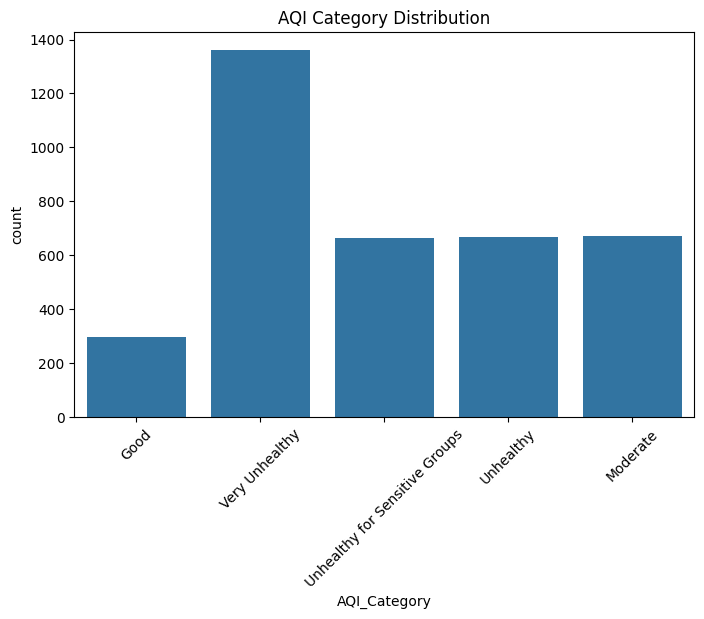

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='AQI_Category', data=df)
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.show()

Most records belong to Moderate and Unhealthy categories. This indicates that many cities experience polluted air conditions frequently.

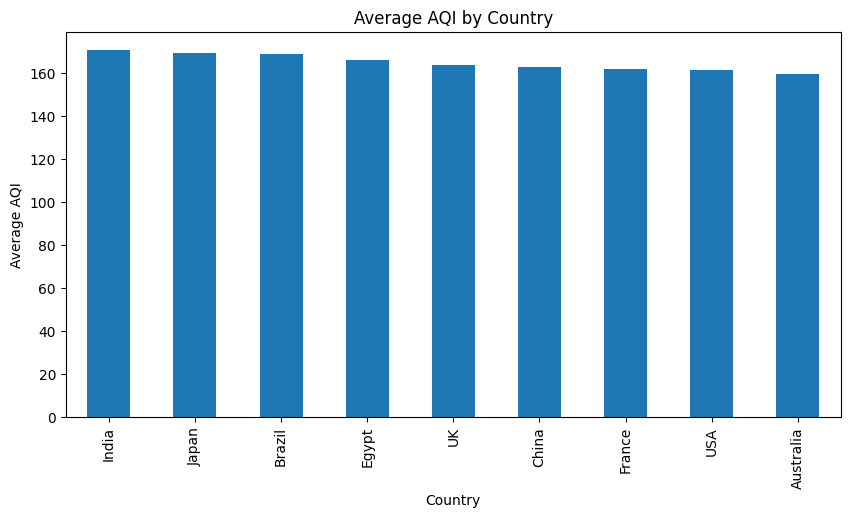

In [10]:
country_aqi = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_aqi.plot(kind='bar')
plt.title("Average AQI by Country")
plt.ylabel("Average AQI")
plt.show()

Some countries have significantly higher AQI values, showing worse air pollution compared to others.

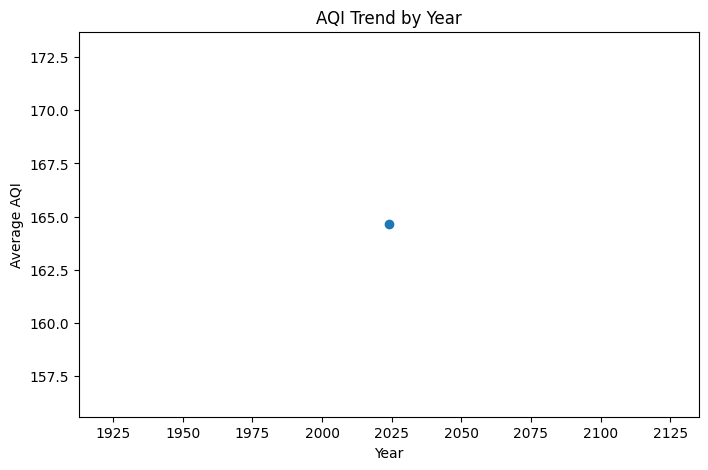

In [11]:
yearly_aqi = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(8,5))
yearly_aqi.plot(marker='o')
plt.title("AQI Trend by Year")
plt.ylabel("Average AQI")
plt.show()

The chart shows how AQI changed over time between 2015 and 2025.

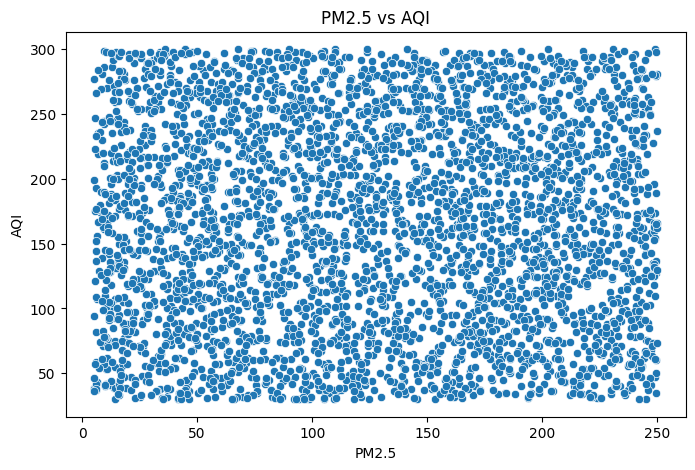

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='PM2.5', y='AQI', data=df)
plt.title("PM2.5 vs AQI")
plt.show()

Higher PM2.5 values generally increase AQI, showing a strong relationship between particulate matter and air pollution.

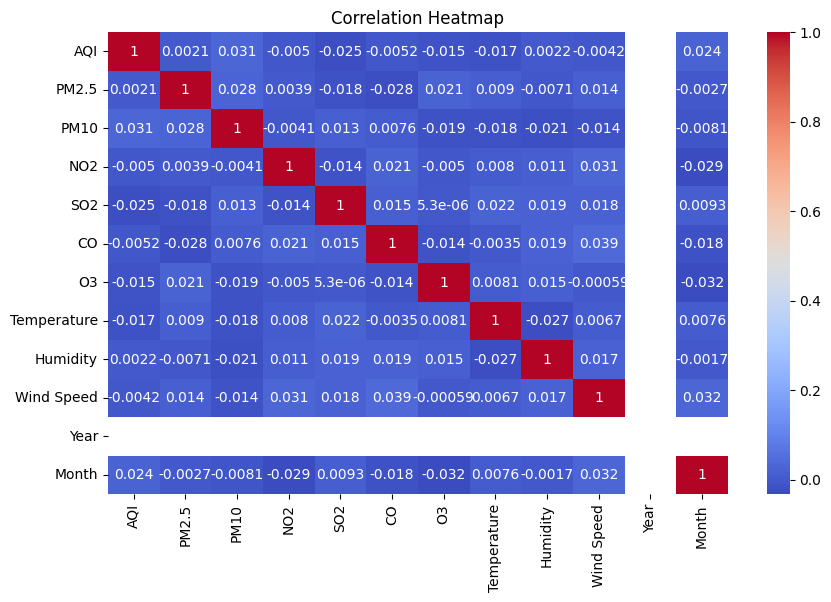

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships among numerical variables. AQI has positive correlation with several pollutants.

In [25]:
features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
            'Temperature', 'Humidity', 'Wind Speed']

X = df[features]
y = df['AQI_Category']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
knn3 = KNeighborsClassifier(n_neighbors=3)

knn3.fit(X_train_scaled, y_train)

pred3 = knn3.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred3))

print(confusion_matrix(y_test, pred3))

print(classification_report(y_test, pred3))

Accuracy: 0.20765027322404372
[[ 6 16 10  4 27]
 [25 35 26  8 48]
 [20 23 20  9 42]
 [20 34 15 14 47]
 [48 79 47 32 77]]
                                precision    recall  f1-score   support

                          Good       0.05      0.10      0.07        63
                      Moderate       0.19      0.25      0.21       142
                     Unhealthy       0.17      0.18      0.17       114
Unhealthy for Sensitive Groups       0.21      0.11      0.14       130
                Very Unhealthy       0.32      0.27      0.29       283

                      accuracy                           0.21       732
                     macro avg       0.19      0.18      0.18       732
                  weighted avg       0.23      0.21      0.21       732



In [30]:
knn5 = KNeighborsClassifier(n_neighbors=5)

knn5.fit(X_train_scaled, y_train)

pred5 = knn5.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred5))

Accuracy: 0.23633879781420766


In [31]:
knn7 = KNeighborsClassifier(n_neighbors=7)

knn7.fit(X_train_scaled, y_train)

pred7 = knn7.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred7))

Accuracy: 0.25


The best k value is the one with highest accuracy.

In [32]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, nb_pred))

print(confusion_matrix(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Accuracy: 0.3866120218579235
[[  0   0   0   0  63]
 [  0   0   0   0 142]
 [  0   0   0   0 114]
 [  0   0   0   0 130]
 [  0   0   0   0 283]]
                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        63
                      Moderate       0.00      0.00      0.00       142
                     Unhealthy       0.00      0.00      0.00       114
Unhealthy for Sensitive Groups       0.00      0.00      0.00       130
                Very Unhealthy       0.39      1.00      0.56       283

                      accuracy                           0.39       732
                     macro avg       0.08      0.20      0.11       732
                  weighted avg       0.15      0.39      0.22       732



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Compare the accuracies of KNN and Naive Bayes. The model with higher accuracy performed better.

In [33]:
X_cluster = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Cluster'] + features].groupby('Cluster').mean()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
Cluster,,,,,,,,,
0,120.941091,163.081245,73.083717,26.100000,5.462890,107.870588,13.456436,69.364876,8.579966
1,132.130063,164.541209,61.254631,23.484537,4.832857,100.342543,16.577316,27.461538,7.833359
2,125.602061,136.518384,24.790272,28.365210,4.799860,108.099176,15.022836,56.928277,6.977246


Cluster 0 represents low pollution areas.
Cluster 1 represents medium pollution areas.
Cluster 2 represents highly polluted areas.

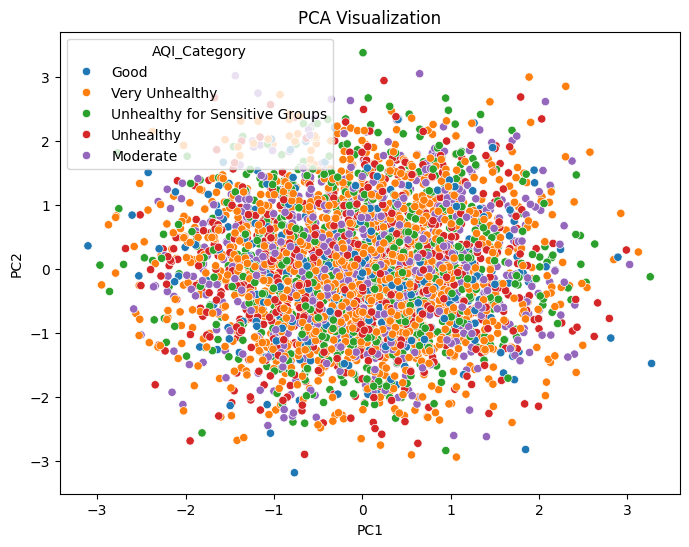

Explained Variance Ratio:
[0.12035055 0.1155008 ]


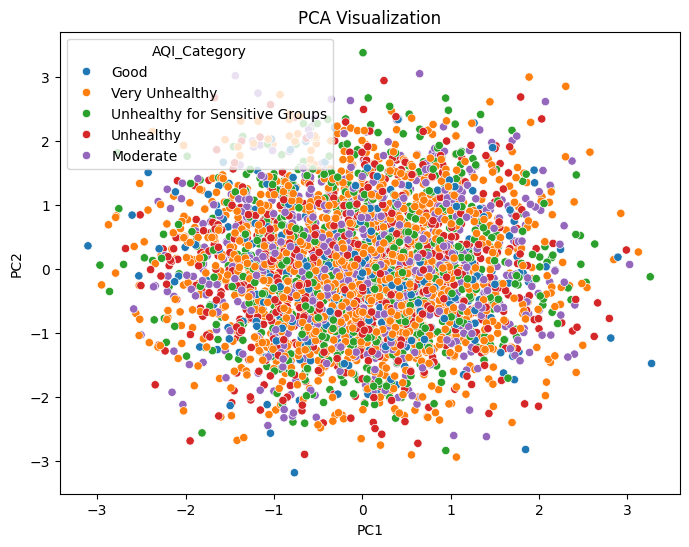

Explained Variance Ratio:
[0.12035055 0.1155008 ]


In [35]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PC1'] = pca_result[:,0]
df['PC2'] = pca_result[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='AQI_Category',
    data=df
)

plt.title("PCA Visualization")
plt.show()

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA helped reduce high-dimensional data into two dimensions, making pollution patterns easier to visualize.

| Method      | Type                     | Purpose               | Main Result    |
| ----------- | ------------------------ | --------------------- | -------------- |
| KNN         | Supervised               | Predict AQI category  | Accuracy = ___ |
| Naive Bayes | Supervised               | Predict AQI category  | Accuracy = ___ |
| K-Means     | Unsupervised             | Group similar records | Clusters = 3   |
| PCA         | Dimensionality Reduction | Visualization         | Variance = ___ |


This project analyzed global air quality data using data science techniques. Data cleaning, visualization, machine learning, clustering, and PCA were successfully applied. KNN and Naive Bayes were used for AQI category prediction, while K-Means and PCA helped discover pollution patterns.